# Cancer Prediction using Logistic Regression

## Introduction

Cancer is one of the leading causes of death worldwide. Early detection plays a crucial role in improving survival rates and enabling effective treatment. With the increasing availability of healthcare data, machine learning techniques can assist medical professionals in predicting disease risk based on patient information.

In this project, we build a **Logistic Regression classification model** to predict whether a patient is likely to have cancer based on several medical diagnostic features. Logistic Regression is a widely used supervised learning algorithm for **binary classification problems**, where the goal is to predict one of two possible outcomes.

The workflow of this project includes:

- Data loading and exploration  
- Data preprocessing and feature scaling  
- Splitting the dataset into training and testing sets  
- Training a Logistic Regression model  
- Evaluating the model using classification metrics  


## Importing Libraries

In [303]:
import pandas as pd 
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

## Loading Dataset

In [304]:
df = pd.read_csv('appendix_cancer_prediction_dataset.csv')

## Exploratory Data Analysis

In [305]:
df.head(10)

,Patient_ID,Country,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,...,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Diagnosis_Delay_Days,Treatment_Type,Survival_Years_After_Diagnosis,Appendix_Cancer_Prediction
0,PID_000001,China,67,Female,28.6,No,Low,Yes,No,Diabetes,...,228,8.1,4.4,361,Negative,Mild,691,Surgery,6.5,Yes
1,PID_000002,Saudi Arabia,83,Female,19.4,No,Low,No,No,Diabetes,...,186,9.7,6.2,235,Negative,Moderate,275,Chemotherapy,1.6,No
2,PID_000003,France,52,Female,17.2,No,Low,Yes,No,Diabetes,...,231,8.2,4.6,269,Negative,Moderate,668,Chemotherapy,0.7,No
3,PID_000004,Russia,71,Male,31.8,Yes,Low,No,No,NaN,...,151,6.8,6.0,193,Negative,Moderate,256,Radiation,2.1,No
4,PID_000005,USA,19,Female,17.7,No,Low,No,No,Hypertension,...,236,6.7,4.9,396,Negative,Mild,370,Radiation,0.5,No
5,PID_000006,USA,44,Male,21.2,No,Low,No,Yes,Hypertension,...,270,6.9,4.9,397,Negative,Mild,309,Radiation,3.7,No
6,PID_000007,USA,43,Female,26.4,No,Low,Yes,No,NaN,...,224,10.3,4.6,355,Negative,Moderate,359,Surgery,8.6,Yes
7,PID_000008,Japan,87,Female,21.3,No,Moderate,No,No,NaN,...,194,6.2,4.5,375,Negative,Moderate,479,Surgery,4.9,No
8,PID_000009,Russia,60,Male,19.7,No,High,No,No,NaN,...,165,6.3,4.9,277,Negative,Severe,402,Surgery,5.0,No
9,PID_000010,UK,47,Male,20.1,Yes,High,No,No,Hypertension,...,266,6.4,5.5,218,Negative,Mild,294,Surgery,5.0,No


In [306]:
df.tail(10)

,Patient_ID,Country,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,...,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Diagnosis_Delay_Days,Treatment_Type,Survival_Years_After_Diagnosis,Appendix_Cancer_Prediction
259990,PID_259991,China,29,Male,28.3,No,Low,No,No,Hypertension,...,208,6.2,4.4,267,Negative,Moderate,378,Radiation,10.5,No
259991,PID_259992,India,51,Male,19.1,No,Moderate,No,No,NaN,...,288,6.2,4.9,392,Negative,Mild,489,Radiation,2.5,Yes
259992,PID_259993,Russia,67,Female,30.2,Yes,Moderate,No,No,NaN,...,295,7.8,5.4,363,Negative,Mild,362,Surgery,1.6,No
259993,PID_259994,France,47,Female,20.8,No,Low,No,No,NaN,...,281,6.9,4.9,355,Negative,Moderate,182,Surgery,7.8,No
259994,PID_259995,Brazil,89,Male,26.6,No,Moderate,No,No,Hypertension,...,258,7.4,4.7,379,Negative,Severe,569,NaN,1.5,No
259995,PID_259996,USA,33,Male,22.3,No,Low,No,No,Diabetes,...,159,7.5,5.2,344,Negative,Moderate,67,Surgery,1.7,No
259996,PID_259997,Australia,45,Female,27.5,Yes,Moderate,Yes,No,Hypertension,...,268,8.0,5.0,195,Negative,Moderate,578,Radiation,0.4,Yes
259997,PID_259998,South Africa,76,Male,27.9,Yes,Moderate,No,No,NaN,...,156,7.8,5.5,201,Positive,Moderate,670,Chemotherapy,0.0,No
259998,PID_259999,China,68,Female,24.0,No,Low,No,No,NaN,...,226,7.9,5.1,386,Negative,Moderate,316,Radiation,8.1,No
259999,PID_260000,Brazil,56,Female,22.7,No,Low,No,Yes,NaN,...,270,6.0,4.8,339,Negative,Moderate,687,Surgery,7.3,No


In [307]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Cancer', 'Genetic_Mutations',
       'Chronic_Diseases', 'Physical_Activity_Level', 'Diet_Type',
       'Radiation_Exposure', 'Previous_Cancers', 'Blood_Pressure',
       'Cholesterol_Level', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count',
       'Platelet_Count', 'Tumor_Markers', 'Symptom_Severity',
       'Diagnosis_Delay_Days', 'Treatment_Type',
       'Survival_Years_After_Diagnosis', 'Appendix_Cancer_Prediction'],
      dtype='object')

In [308]:
df.shape

(260000, 25)

In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260000 entries, 0 to 259999
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Patient_ID                      260000 non-null  object 
 1   Country                         260000 non-null  object 
 2   Age                             260000 non-null  int64  
 3   Gender                          260000 non-null  object 
 4   BMI                             260000 non-null  float64
 5   Smoking_Status                  260000 non-null  object 
 6   Alcohol_Consumption             260000 non-null  object 
 7   Family_History_Cancer           260000 non-null  object 
 8   Genetic_Mutations               260000 non-null  object 
 9   Chronic_Diseases                129913 non-null  object 
 10  Physical_Activity_Level         260000 non-null  object 
 11  Diet_Type                       260000 non-null  object 
 12  Radiation_Exposu

In [310]:
df.isnull().sum()

Patient_ID                             0
Country                                0
Age                                    0
Gender                                 0
BMI                                    0
Smoking_Status                         0
Alcohol_Consumption                    0
Family_History_Cancer                  0
Genetic_Mutations                      0
Chronic_Diseases                  130087
Physical_Activity_Level                0
Diet_Type                              0
Radiation_Exposure                     0
Previous_Cancers                       0
Blood_Pressure                         0
Cholesterol_Level                      0
White_Blood_Cell_Count                 0
Red_Blood_Cell_Count                   0
Platelet_Count                         0
Tumor_Markers                          0
Symptom_Severity                       0
Diagnosis_Delay_Days                   0
Treatment_Type                     26074
Survival_Years_After_Diagnosis         0
Appendix_Cancer_

In [311]:
df = df.drop(df[['Patient_ID','Country']],axis=1)

In [312]:
cols = ['Smoking_Status','Family_History_Cancer','Genetic_Mutations','Radiation_Exposure','Previous_Cancers','Appendix_Cancer_Prediction']
df[cols]=df[cols].replace({'Yes':1,'No':0})

C:\Users\KIIT\AppData\Local\Temp\ipykernel_34860\4198948054.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols]=df[cols].replace({'Yes':1,'No':0})


In [313]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0,'Other':2})

In [314]:
df[['Alcohol_Consumption','Physical_Activity_Level']] = df[['Alcohol_Consumption','Physical_Activity_Level']].replace({'Low':0,'Moderate':1,'High':2})

C:\Users\KIIT\AppData\Local\Temp\ipykernel_34860\3068494910.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['Alcohol_Consumption','Physical_Activity_Level']] = df[['Alcohol_Consumption','Physical_Activity_Level']].replace({'Low':0,'Moderate':1,'High':2})


In [315]:
#df['Chronic_Diseases'] = df['Chronic_Diseases'].replace({'None':0,'Hypertension':1,'Diabetes':2})
#df['Chronic_Diseases'].unique()
#df['Chronic_Diseases'] = df['Chronic_Diseases'].fillna(df['Chronic_Diseases'].mode())
df['Chronic_Diseases'] = df['Chronic_Diseases'].replace({
    'Hypertension': 1,
    'Diabetes': 2
}).fillna(0)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_34860\4185259605.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Chronic_Diseases'] = df['Chronic_Diseases'].replace({


In [316]:
df['Diet_Type'] = df['Diet_Type'].map({'Vegan':0, 'Vegetarian':1,'Non-Vegetarian':2})

In [317]:
df['Tumor_Markers'] = df['Tumor_Markers'].map({'Negative':0,'Positive':1})

In [318]:
df['Symptom_Severity'] = df['Symptom_Severity'].map({'Mild':0,'Moderate':1,'Severe':2})

In [319]:
#df['Treatment_Type'] = df['Treatment_Type'].replace({'None':0,'Chemotherapy':1,'Surgery':2,'Radiation':3})
#df['Treatment_Type'] = df['Treatment_Type'].fillna(df['Treatment_Type'].mode())
df['Treatment_Type'] = df['Treatment_Type'].replace({
    'None': 0,
    'Chemotherapy': 1,
    'Surgery': 2,
    'Radiation': 3
}).fillna(0)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_34860\2908304119.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Treatment_Type'] = df['Treatment_Type'].replace({


In [320]:
df.isnull().sum()

Age                               0
Gender                            0
BMI                               0
Smoking_Status                    0
Alcohol_Consumption               0
Family_History_Cancer             0
Genetic_Mutations                 0
Chronic_Diseases                  0
Physical_Activity_Level           0
Diet_Type                         0
Radiation_Exposure                0
Previous_Cancers                  0
Blood_Pressure                    0
Cholesterol_Level                 0
White_Blood_Cell_Count            0
Red_Blood_Cell_Count              0
Platelet_Count                    0
Tumor_Markers                     0
Symptom_Severity                  0
Diagnosis_Delay_Days              0
Treatment_Type                    0
Survival_Years_After_Diagnosis    0
Appendix_Cancer_Prediction        0
dtype: int64

## Model

In [321]:
y = df.Appendix_Cancer_Prediction

In [322]:
x = df[[
'Age',
'BMI',
'Family_History_Cancer',
'Genetic_Mutations',
'Radiation_Exposure',
'Blood_Pressure',
'Cholesterol_Level',
'White_Blood_Cell_Count',
'Red_Blood_Cell_Count',
'Platelet_Count',
'Tumor_Markers'
]]

### Train-Test Split

In [323]:
x_train,x_test,y_train,y_test = train_test_split(x,y,stratify=y,test_size=0.2)

### Feature Scaling

In [324]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [325]:
model = linear_model.LogisticRegression(class_weight='balanced', max_iter=2000)
model.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

## Model Prediction

In [326]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 0, ..., 1, 1, 0], dtype=int64)

## Model Evaluation

In [327]:
model.score(x_test,y_test)

0.5065384615384615

In [328]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.51      0.64     44143
           1       0.15      0.49      0.23      7857

    accuracy                           0.51     52000
   macro avg       0.50      0.50      0.43     52000
weighted avg       0.74      0.51      0.58     52000



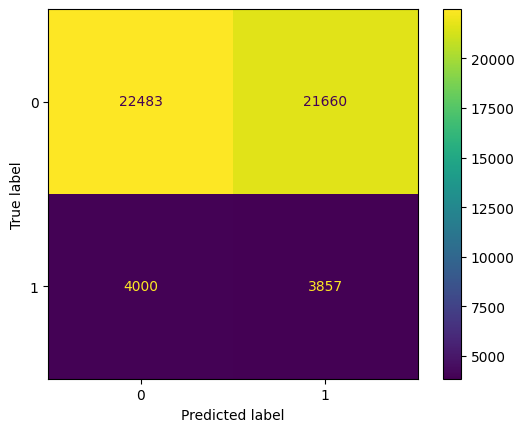

In [329]:
ConfusionMatrixDisplay.from_estimator(model,x_test,y_test)

<Axes: >

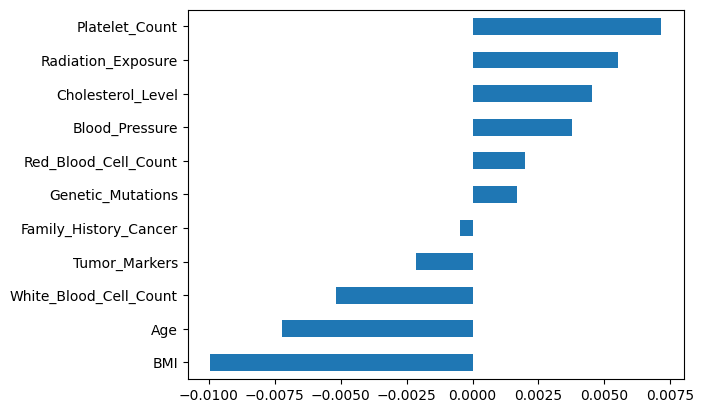

In [330]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values()
importance.plot(kind='barh')

## Conclusion

In this project, a machine learning model was developed to predict the likelihood of cancer using clinical and biological features. The workflow included data preprocessing, feature selection, feature scaling, and training a Logistic Regression classification model.

The model was evaluated using multiple metrics including accuracy, precision, recall, and F1-score. Due to class imbalance and limited predictive signal within the dataset, the model achieved an accuracy of approximately 50% and a recall of about 0.49. While the overall accuracy is moderate, the evaluation highlights the challenges associated with imbalanced medical datasets.

This project demonstrates the complete machine learning pipeline, including data preparation, model training, and performance evaluation. It also highlights the importance of selecting appropriate evaluation metrics and handling class imbalance when working with healthcare data.

Future improvements could include more advanced feature engineering, hyperparameter tuning, and experimenting with more complex machine learning algorithms to improve predictive performance.